<a href="https://colab.research.google.com/github/vgasztany/thesis/blob/main/gasztany_vivien_r_gauges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#' Szükséges csomagok és könyvtárak
install.packages('forecast', dependencies = TRUE)
remotes::install_github("robjhyndman/forecast")
library(forecast)
library(lubridate)
library(readr)
library(urca)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘x13binary’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘forecTheta’, ‘rticles’, ‘seasonal’, ‘uroot’





rlang (1.1.5 -> 1.1.6) [CRAN]


Installing 1 packages: rlang

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp3MxZPB/remotes18569d04c67/robjhyndman-forecast-cfa8ef3/DESCRIPTION’ ... OK
* preparing ‘forecast’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘forecast_8.24.0.9000.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [ ]:
#' Adatok letöltése a google drive-ról és a megfelelő formátum létrehozása
#' @data: vízügyi adatbázis összes adata
#' @dates: a szegedi mérések időpontjai
#' @values: a szegedi mérések értékei
#' @time_series: a szegedi mérések idősor formátumban

system("gdown --id 1Q2e5630PNqasosgf1XV1olflYjtFaIkg")
data = read.csv("1951_2020_allgauges.csv")

#convert it to time series
dates <- as.Date(data$X)
values <- data$X2275
time_series <- ts(values, start = c(year(dates[1]),1), frequency = 365)

In [ ]:
#' Az ADF teszt futtatása az adatainkon, hogy meggyőződjünk az idősor stacionaritásáról
#' @adf_test: összefoglaló az ADF teszt eredményéről

adf_test <- ur.df(time_series, lags = 0, type = "drift")
summary(adf_test)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1)

Residuals:
     Min       1Q   Median       3Q      Max 
-118.543   -9.305   -1.619    6.428  217.477 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.9517794  0.1745262   5.454 4.98e-08 ***
z.lag.1     -0.0045583  0.0005948  -7.663 1.87e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 19.39 on 25565 degrees of freedom
Multiple R-squared:  0.002292,	Adjusted R-squared:  0.002253 
F-statistic: 58.73 on 1 and 25565 DF,  p-value: 1.874e-14


Value of test-statistic is: -7.6635 29.368 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.43 -2.86 -2.57
phi1  6.43  4.59  3.78


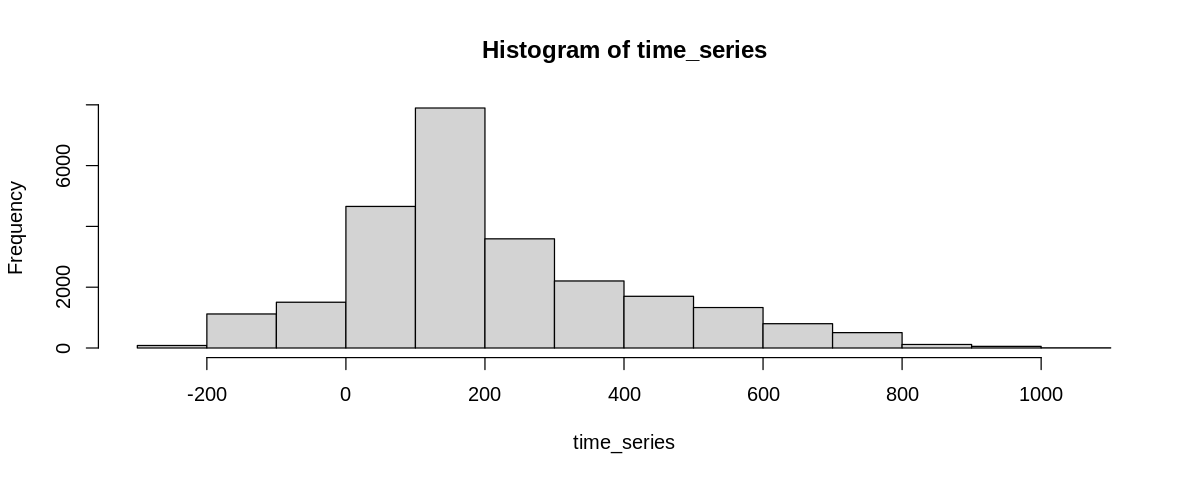

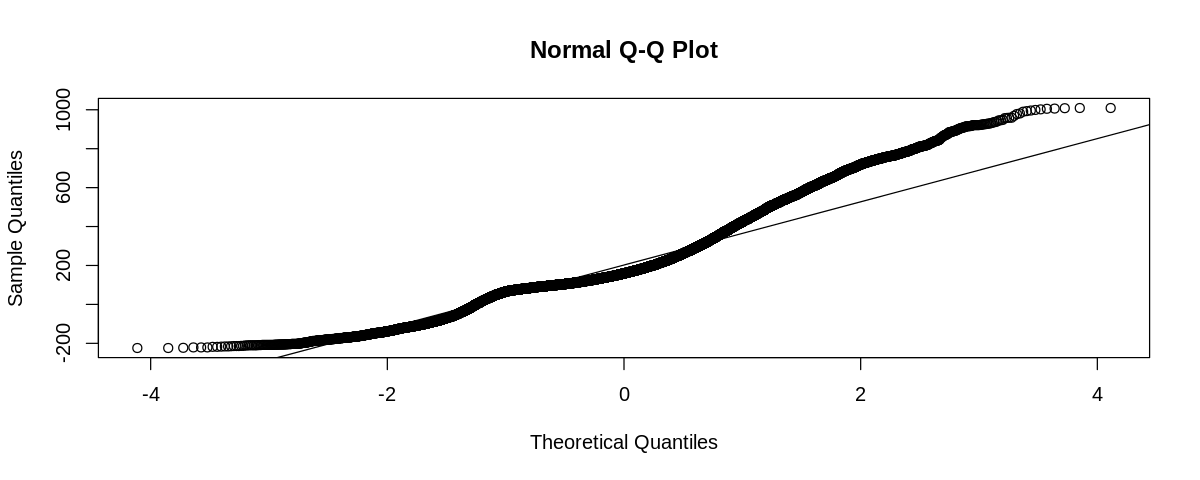

In [ ]:
#' Az idősor hisztogramja és Q-Q grafikonja.

hist(time_series)
qqnorm(time_series)
qqline(time_series)

#' light tailed

In [ ]:
#' Megadjuk a teszt adathalmaz méretét és ennek megfelelően szétvágjuk az idősort
#' tanuló és teszt halmazra.
#' @percent: A teszt halmaz mérete a teljes idősorhoz mérten, százalékban megadva.
#' @outset_size: Meghatározza a teszt halmaz adatainak a számát.
#' @outset: A teszt halmaz értékei idősorként megadva.
#' @inset: A tanuló halmaz értékei idősorként megadva.

percent <- 0.2
outset_size <- ceiling(length(time_series) * percent)
outset <- tail(time_series, outset_size)
inset <- head(time_series, length(time_series) - outset_size)
print(length(time_series))
print(length(inset))
print(length(outset))

[1] 25568
[1] 20454
[1] 5114


In [ ]:
#' Normalizációs függvény
#' @param x A normalizálni kívánt adatok.
#' @param y A normalizáció paramétere.

normalize <- function(x, y) {
  (x - min(x)) / (max(y) - min(y))
}

In [ ]:
#' Denormalizációs függvény
#' @param x A denormalizálni kívánt adatok.
#' @param y A denormalizáció paramétere.
#' @param z Az eredeti x adatok.

denormalize <- function(x, y, z) {
  (x * (max(y) - min(y)) + min(z))
}

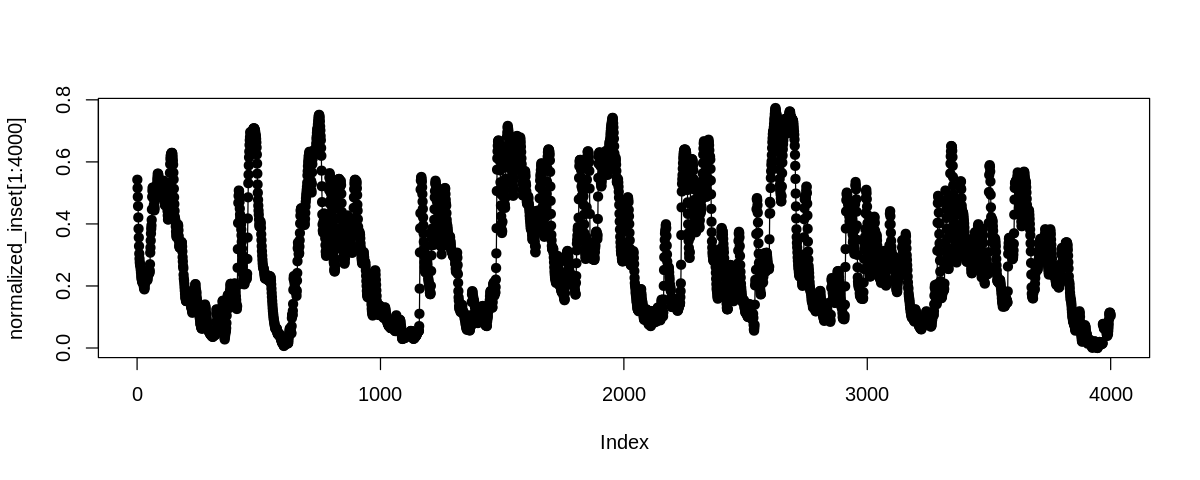

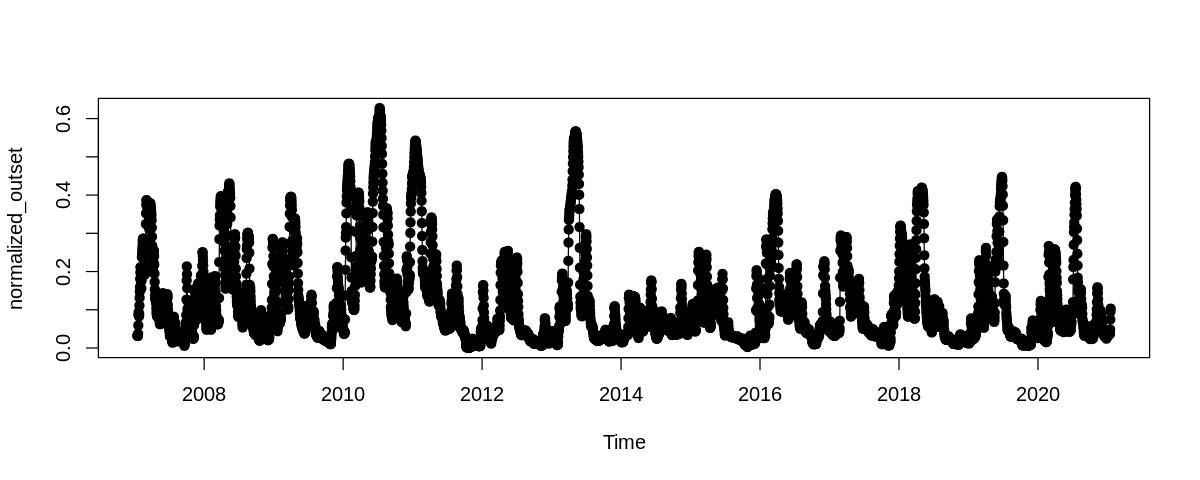

In [ ]:
#' Az idősorok normalizációja
#' @normalized_inset: A normalizált tanulóhalmaz.
#' @normalized_outset: A tanulóhalmaz által normalizált teszthalmaz.

normalized_inset <- normalize(inset, inset)
plot(normalized_inset[1:4000], type = "o", pch = 19)
normalized_outset <- normalize(outset, inset)
plot(normalized_outset, type = "o", pch = 19)

In [ ]:
#' A paraméter rács meghatározása, amely alapján a modellünket tanítani fogjuk, ezek az értékek a modellünk hiperparaméterei.
#' @p_values: A létrehozni kívánt mátrix soraiban lévő azon elemek száma, amelyeken a tanítást fogjuk elvégezni.
#' @decay_values: A neurális háló súlyait megszorzó érték.
#' @size_values: A neurális háló rejtett rétegeinek a száma.

p_values <- seq(1, 21, by = 3)
decay_values <- c(0, 0.00316, 0.0147, 0.05, 0.075, 0.1)
size_values <- seq(3, 15, by = 3)

In [ ]:
#' 5-fold CV

#' Létrehozunk egy csv file-t, amelybe kimentjük azon hiperparaméter kombinációkat és azok RMSE-t, amelyeket már vizsgáltunk.
if (file.exists("all_params_and_RMSE.csv")) {
  all_params_and_RMSE <- read.csv("all_params_and_RMSE.csv")
  #' Frissítjük a Ljung-Box teszt értéket
  last_row = tail(all_params_and_RMSE, n = 1)
  faild_Ljung_Box_tests = last_row$lj_b
} else {
  #' Ha még nem volt mentett paraméter, vagy fájl, akkor a kezdő értékeket állítsuk be és hozzuk létre a csv-t.
  all_params_and_RMSE <- data.frame(p = integer(), decay = numeric(), q = numeric(), RMSE = numeric())
  write.csv(all_params_and_RMSE, file = "all_params_and_RMSE.csv", row.names = FALSE)
  faild_Ljung_Box_tests = 0
}

#' Létrehozunk egy csv file-t, amelybe kimentjük azon hiperparaméter kombinációt amelynek a legalacsonyabb az RMSE-e azok közül, amelyeket már vizsgáltunk.
if (file.exists("best_params.csv")) {
  best_params_df <- read.csv("best_params.csv")
  best_params <- list(p = best_params_df$p, decay = best_params_df$decay, q = best_params_df$q)
  lowest_RMSE <- best_params_df$RMSE
} else {
  best_params = NULL
  lowest_RMSE = NULL
  best_modelcv = NULL
}

#' Végig iterálunk a paraméterrácson.
for (p_index in 1:length(p_values)){
  p <- p_values[p_index]
  for (d_index in 1:length(decay_values)){
    d <- decay_values[d_index]
    for (q_index in 1:length(size_values)){
      q <- size_values[q_index]
      actual_params = c(p,d,q)
      #' Ellenőrizzük, hogy az éppen vizsgált hiperparaméter kombináció volt-e már vizsgálva. Amennyiben igen, úgy ezt az iterációt átugorjuk.
      if (!any(apply(all_params_and_RMSE[, 1:3], 1, function(row) all(row == actual_params)))) {
        #' Meghívjuk a forecast csomag CVar() függvényét, amely K-fold keresztvalidációt végzi el a megadott adatokon, valamint a Ljung-box tesztet.
        modelcv <- CVar(normalized_inset, k = 5, p = p, decay = d, size = q, LBlags = 20)
        #' @faild_Ljung_Box_tests: Azon esetek száma, amelyeknél a reziduálok korreláltak.
        if(modelcv$LBpvalue < 0.05){
          faild_Ljung_Box_tests <- faild_Ljung_Box_tests + 1
        }
        #' Amennyiben a modell átment a Ljung-Box teszten és jobb RMSE-t produkált mint a korábbi, úgy legyen ennek a hiperparaméterezése a legjobb.
        if (modelcv$LBpvalue >= 0.05 && is.null(lowest_RMSE)){
          lowest_RMSE <- modelcv$CVsummary[2][1]
          best_params <- list(p = p, decay = d, q = q)
          best_modelcv <- modelcv
          #' Kimentése a legjobb paraméter és RMSE értékének egy CSV-fájlba
          best_params_df <- data.frame(p = best_params$p, decay = best_params$decay, q = best_params$q, RMSE = lowest_RMSE)
          write.csv(best_params_df, file = "best_params.csv", row.names = FALSE)

        } else if(modelcv$LBpvalue >= 0.05 && !is.null(lowest_RMSE) && lowest_RMSE > modelcv$CVsummary[2][1]){
          lowest_RMSE <- modelcv$CVsummary[2][1]
          best_params <- list(p = p, decay = d, q = q)
          best_modelcv <- modelcv
          #' Kimentése a legjobb paraméter és RMSE értékének egy CSV-fájlba
          best_params_df <- data.frame(p = best_params$p, decay = best_params$decay, q = best_params$q, RMSE = lowest_RMSE)
          write.csv(best_params_df, file = "best_params.csv", row.names = FALSE)
        }
        #' Kimentése a már lefutott paramétereknek és a kapott RMSE-nek a csv-be.
        new_row <- data.frame(p = p, decay = d, q = q, RMSE = modelcv$CVsummary[2][1], lj_b = faild_Ljung_Box_tests)
        all_params_and_RMSE <- rbind(all_params_and_RMSE, new_row)
        write.csv(all_params_and_RMSE, file = "all_params_and_RMSE.csv", row.names = FALSE)
      } else {
         #' Ha az aktuális paraméterkombináció már szerepel az eddig lefutottak között, lépjünk tovább.
        next
      }
    }
  }
}
if (!is.null(best_params) && !is.null(lowest_RMSE)) {
  cat("Best parameters: p=", best_params$p, " decay=", best_params$decay, " q=", best_params$q, "\n", "Lowest RMSE:", lowest_RMSE, "\n", "Number of failed Ljung-Box tests:", faild_Ljung_Box_tests)
} else {
  cat("No best parameters found.\n")
}

Best parameters: p= 10  decay= 0  q= 9 
 Lowest RMSE: 0.008549892 
 Number of failed Ljung-Box tests: 149

In [ ]:
#' Futtatjuk a legjobb modelt a normalizált teszt adatokon.
best_model_on_out_set <- nnetar(normalized_outset, model = best_modelcv$fold1$model, xreg=best_modelcv$xreg)
fit_best_model_on_out_set <- fitted(best_model_on_out_set)
#' Denormalizáljuk a becsült teszt adatokat, hogy összehasonlítható legyen az eredeti teszt adatokkal.
denormalized_fitted_model <- denormalize(fit_best_model_on_out_set, inset, outset)
#' Meghatározzuk a becslés pontosságát (RMSE)
acc_best_model_on_out_set <- accuracy(outset, denormalized_fitted_model)
cat("RMSE: ", acc_best_model_on_out_set[2][1], "\n")

RMSE:  7.974018 


Warning message:
“Removed 365 rows containing missing values (`geom_line()`).”


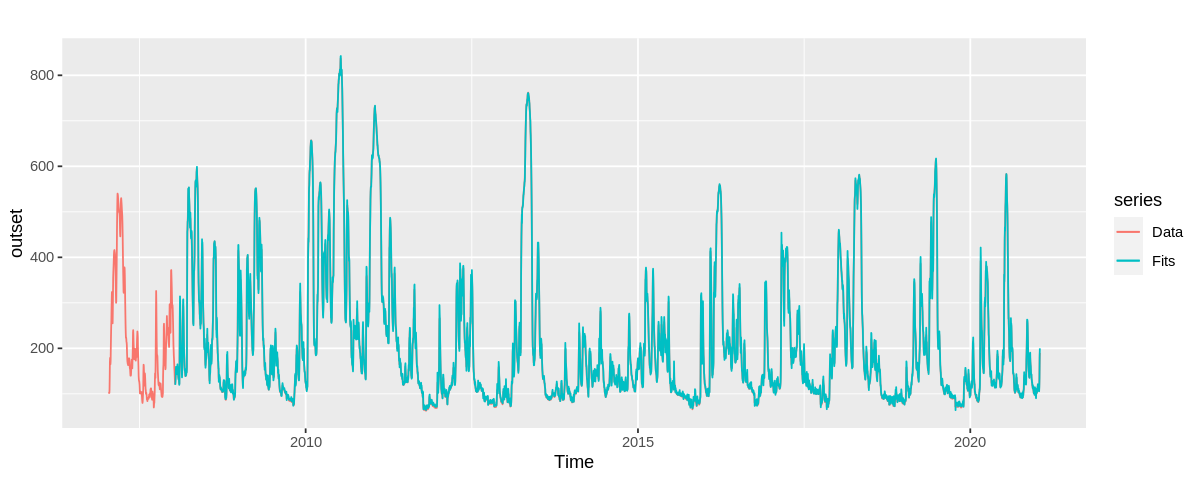

In [ ]:
library(ggplot2)

autoplot(outset, series="Data") +
  autolayer(denormalized_fitted_model, series="Fits")

In [ ]:
#' OOS kiértékelést elvégző függvény.
#' @param inset: Azon adatok, amelyek a modell tanítását és validálását szeretnénk elvégezni.
#' @param test_set_size_percent: Az a százalékos érték amekkora részén szeretnénk az adatoknak a validálást elvégezni.
#' @param p: A létrehozni kívánt mátrix soraiban lévő azon elemek száma, amelyeken a tanítást fogjuk elvégezni.
#' @param decay: A neurális háló súlyait megszorzó érték.
#' @param q: A neurális háló rejtett rétegeinek a száma.

OOS <- function(inset, test_set_size_percent = NULL, p=NULL, decay=NULL, q=NULL){
  #' Létrehozunk egy listát 0 és 1-es értékekből, amelynek hossza megegyezik az adatok számával. A 0-k száma a tanuló halmaz elemeinek számával és 1-esek száma a tanító halmaz elemeinek a számával egyezik meg.
  nx <- length(inset)
  ind <- seq_len(nx)
  zero = rep(1, length.out = ceiling(nx)*test_set_size_percent)
  one = rep(0, length.out = length(inset)-ceiling(nx)*test_set_size_percent)
  fold <- sort(c(zero, one))

  out <- list()
  alltestfit <- rep(NA, length.out = nx)
  #' Két index listát hozunk létre az alapján, hogy mely adatok kerülnek majd a tanuló és teszt halmazba.
  testset <- ind[fold == 1]
  trainset <- ind[fold == 0]
  #' Meghívjuk a forecast csomag nnetar() függvényét, amely elvégzi a modell tanítását a megadott hiperparaméterek mellett a tanító halmazon.
  trainmodel <- nnetar(inset, subset = trainset, p = p, decay = decay, size = q)
  #' Meghívjuk a forecast csomag nnetar() függvényét, amelynek ha megadjuk a modell paraméterét, akkor csak futtatja a megadott modellt a megadott adatokra.
  testmodel <- nnetar(inset, model = trainmodel, xreg = trainmodel$xreg)
  #' Futtatjuk a modellt, majd kiértékeljük a teszt halmazon.
  testfit <- fitted(testmodel)
  acc <- accuracy(inset, testfit, test = testset)

  #' A visszatérési értékei a függvénynek, amellyel újra futtathatóvá válik a modell.
  out$model <- trainmodel
  out$accuracy <- acc
  out$testfit <- ts(testfit)
  tsp(out$testfit) <- tsp(inset)
  out$test_set <- testset
  #' A reziduálok kiszámítása.
  out$residuals <- out$testfit - inset
  #' A Ljung-Box teszt futtatása.
  out$LBpvalue <- Box.test(out$residuals, type = "Ljung", lag = 20)$p.value

  return(structure(out, class = c("OOS", class(trainmodel))))
}

In [ ]:
#' OOS-kiértékelés

#' Létrehozunk egy csv file-t, amelybe kimentjük azon hiperparaméter kombinációkat és azok RMSE-t, amelyeket már vizsgáltunk.
if (file.exists("OOS_all_params_and_RMSE.csv")) {
  OOS_all_params_and_RMSE <- read.csv("OOS_all_params_and_RMSE.csv")
  # Frissítjük a Ljung-Box teszt értéket
  OOS_last_row = tail(OOS_all_params_and_RMSE, n = 1)
  OOS_faild_Ljung_Box_tests = OOS_last_row$lj_b
} else {
  # Ha még nem volt mentett paraméter, vagy fájl, akkor a kezdő értékeket állítsuk be és hozzuk létre a csv-t
  OOS_all_params_and_RMSE <- data.frame(p = integer(), decay = numeric(), q = numeric(), RMSE = numeric())
  write.csv(OOS_all_params_and_RMSE, file = "OOS_all_params_and_RMSE.csv", row.names = FALSE)
  OOS_faild_Ljung_Box_tests = 0
}

#' Létrehozunk egy csv file-t, amelybe kimentjük azon hiperparaméter kombinációt amelynek a legalacsonyabb az RMSE-e azok közül, amelyeket már vizsgáltunk.
if (file.exists("OOS_best_params.csv")) {
  OOS_best_params_df <- read.csv("OOS_best_params.csv")
  OOS_best_params <- list(p = OOS_best_params_df$p, decay = OOS_best_params_df$decay, q = OOS_best_params_df$q)
  OOS_lowest_RMSE <- OOS_best_params_df$RMSE
} else {
  OOS_best_params = NULL
  OOS_lowest_RMSE = NULL
  OOS_best_model = NULL
}
#' Végig iterálunk a paraméterrácson.
for (p in 1:length(p_values)){
  p <- p_values[p]
  for (d in 1:length(decay_values)){
    d <- decay_values[d]
    for (q in 1:length(size_values)){
      q <- size_values[q]
      OOS_actual_params = c(p,d,q)
      #' Ellenőrizzük, hogy az éppen vizsgált hiperparaméter kombináció volt-e már vizsgálva. Amennyiben igen, úgy ezt az iterációt átugorjuk.
      if (!any(apply(OOS_all_params_and_RMSE[, 1:3], 1, function(row) all(row == OOS_actual_params)))) {
        #' Meghívjuk OOS() függvényét, amely létrehozza a modellt a megadott adatok alapján, valamint elvégzi a Ljung-box tesztet.
        model_OOS <- OOS(normalized_inset, test_set_size_percent = 0.2, p = p, decay = d, q = q)
        #' @OOS_faild_Ljung_Box_tests: Azon esetek száma, amelyeknél a reziduálok korreláltak.
        if(model_OOS$LBpvalue < 0.05){
          OOS_faild_Ljung_Box_tests <- OOS_faild_Ljung_Box_tests + 1
        }
        #' Amennyiben a modell átment a Ljung-Box teszten és jobb RMSE-t produkált mint a korábbi, úgy legyen ennek a hiperparaméterezése a legjobb.
        if(model_OOS$LBpvalue >= 0.05 && is.null(OOS_lowest_RMSE)){
          OOS_lowest_RMSE <- model_OOS$accuracy[2]
          OOS_best_params <- list(p = p, decay = d, q = q)
          OOS_best_model <- model_OOS$model
          # Kimentése a legjobb paraméter és RMSE értékének egy CSV-fájlba
          OOS_best_params_df <- data.frame(p = OOS_best_params$p, decay = OOS_best_params$decay, q = OOS_best_params$q, RMSE = OOS_lowest_RMSE)
          write.csv(OOS_best_params_df, file = "OOS_best_params.csv", row.names = FALSE)
        } else if(model_OOS$LBpvalue >= 0.05 && !is.null(OOS_lowest_RMSE) && OOS_lowest_RMSE > model_OOS$accuracy[2]){
          OOS_lowest_RMSE <- model_OOS$accuracy[2]
          OOS_best_params <- list(p = p, decay = d, q = q)
          OOS_best_model <- model_OOS$model
           # Kimentése a legjobb paraméter és RMSE értékének egy CSV-fájlba
          OOS_best_params_df <- data.frame(p = OOS_best_params$p, decay = OOS_best_params$decay, q = OOS_best_params$q, RMSE = OOS_lowest_RMSE)
          write.csv(OOS_best_params_df, file = "OOS_best_params.csv", row.names = FALSE)
        }
        #Kimentése a már lefutott paramétereknek és a kapott RMSE-nek a csv-be.
        OOS_new_row <- data.frame(p = p, decay = d, q = q, RMSE = model_OOS$accuracy[2], lj_b = OOS_faild_Ljung_Box_tests)
        OOS_all_params_and_RMSE <- rbind(OOS_all_params_and_RMSE, OOS_new_row)
        write.csv(OOS_all_params_and_RMSE, file = "OOS_all_params_and_RMSE.csv", row.names = FALSE)
        } else {
         # Ha az aktuális paraméterkombináció már szerepel az eddig lefutottak között, lépjünk tovább.
        next
      }
    }
  }
}
if (!is.null(OOS_best_params) && !is.null(OOS_lowest_RMSE)) {
  cat("Best parameters: p=", OOS_best_params$p, " decay=", OOS_best_params$decay, " q=", OOS_best_params$q, "\n", "Lowest RMSE:", OOS_lowest_RMSE)
} else {
  cat("No best parameters found.\n")
}

Best parameters: p= 10  decay= 0  q= 15 
 Lowest RMSE: 0.007837724

In [ ]:
#' Futtatjuk a legjobb modelt a normalizált teszt adatokon.
OOS_best_model_on_out_set <- nnetar(normalized_outset, model = OOS_best_model, xreg = OOS_best_model$xreg)
fit_OOS_best_model_on_out_set <- fitted(OOS_best_model_on_out_set)
#' Denormalizáljuk a becsült teszt adatokat, hogy összehasonlítható legyen az eredeti teszt adatokkal.
denormalized_OOS_fitted_model <- denormalize(fit_OOS_best_model_on_out_set, inset, outset)
#' Meghatározzuk a becslés pontosságát (RMSE)
acc_OOS_best_model_on_out_set <- accuracy(outset, denormalized_OOS_fitted_model)
cat("RMSE: ", acc_OOS_best_model_on_out_set[2][1], "\n")


RMSE:  7.992224 


Warning message:
“Removed 365 rows containing missing values (`geom_line()`).”


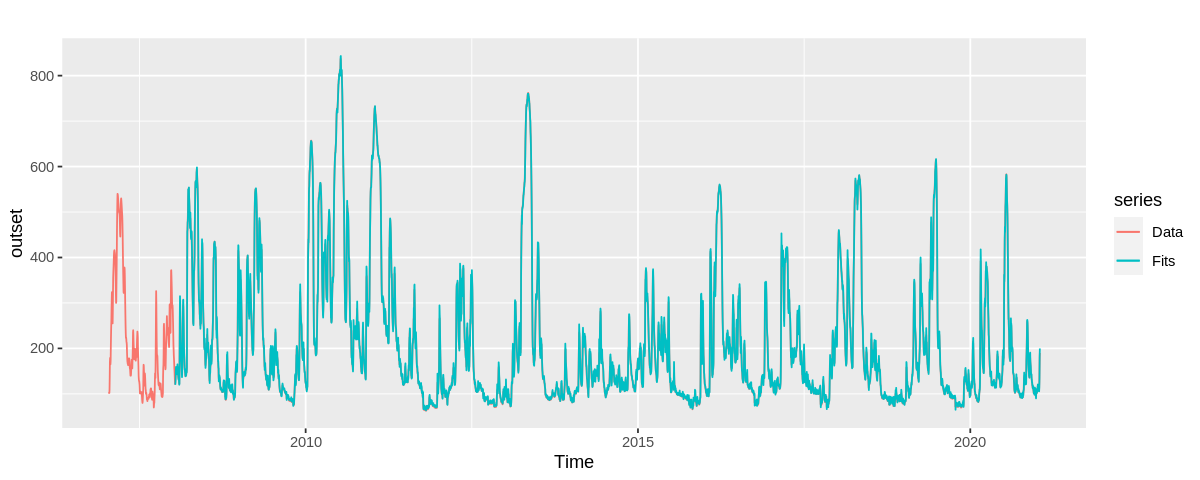

In [ ]:
autoplot(outset, series="Data") +
  autolayer(denormalized_OOS_fitted_model, series="Fits")